In [1]:
import pyreadr
import anndata as ad 
import pandas as pd
import numpy as np
import scanpy as sc 
import os
import rpy2.robjects as ro
from rpy2.robjects import default_converter
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import numpy2ri
from sklearn.preprocessing import StandardScaler
from scipy import sparse

In [24]:
# load RDS, transpose, and extract names 
readRDS = ro.r["readRDS"]
x = readRDS("endo-me_data/M_mat_SmartSVA_corrected.rds")

x_t = ro.r["t"](x)
print(tuple(ro.r["dim"](x_t)))

rownames = list(ro.r["rownames"](x_t))  # sample IDs after transpose
colnames = list(ro.r["colnames"](x_t))  # CpG IDs
print(len(rownames), len(colnames))

(984, 759345)
984 759345


In [25]:
# convert to numpy and build raw AnnData
with localconverter(default_converter + numpy2ri.converter):
    X = np.array(x_t, dtype=np.float32)

adata = ad.AnnData(
    X=X,
    obs=pd.DataFrame(index=pd.Index(rownames, name="sample")),
    var=pd.DataFrame(index=pd.Index(colnames, name="cpg"))
)

print(adata)
print("obs cols:", adata.obs.shape[1])

AnnData object with n_obs × n_vars = 984 × 759345
obs cols: 0


In [26]:
# load the metadata file 
meta = pd.read_excel(
    "endo-me_data/SH-Data Annotation_07.07.20_1.xlsx",
    sheet_name="Batch 1and2",
    dtype=str
)
print(meta.shape)

(1300, 30)


/home/ubuntu/.local/lib/python3.10/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [27]:
# normalize IDs on both sides 
meta["Epic_Complete Bar code"] = meta["Epic_Complete Bar code"].astype(str).str.strip()
adata.obs_names = adata.obs_names.astype(str).str.strip()

In [28]:
annot = meta.set_index("Epic_Complete Bar code")[[
    "Sample ID",
    "Endometriosis (Yes/No)",
    "Endometriosis stage ",
    "Endometriosis stage grouped (I-II), (III-IV) ",
    "Cycle phase for Analysis",
    "Cycle Phase Source",
]].copy()

annot = annot.rename(columns={
    "Sample ID": "sample-id",
    "Endometriosis (Yes/No)": "endo",
    "Endometriosis stage ": "endo-stage",
    "Endometriosis stage grouped (I-II), (III-IV) ": "endo-stage-grouped",
    "Cycle phase for Analysis": "cycle-phase",
    "Cycle Phase Source": "cycle-phase-source",
})

In [29]:
# clean and filter labels 
annot["endo"] = annot["endo"].astype(str).str.strip()
annot = annot[annot["endo"].isin(["Yes", "No"])]

annot["cycle-phase"] = annot["cycle-phase"].astype(str).str.strip()
annot = annot[annot["cycle-phase"] != "Exclude"]

annot["endo"] = annot["endo"].map({"Yes": 1, "No": 0}).astype("Int64")
print("annot rows after filters:", annot.shape[0])

annot rows after filters: 1272


In [30]:
# align samples
common = adata.obs_names.intersection(annot.index)

print("adata samples:", adata.n_obs)
print("annot samples:", annot.shape[0])
print("common samples:", len(common))

adata samples: 984
annot samples: 1272
common samples: 984


In [31]:
# final merged AnnData
adata_final = adata[common].copy()
adata_final.obs = annot.loc[common].copy()

print(adata_final)
print("obs cols:", adata_final.obs.shape[1])
print(adata_final.obs[["endo", "cycle-phase"]].head())

AnnData object with n_obs × n_vars = 984 × 759345
    obs: 'sample-id', 'endo', 'endo-stage', 'endo-stage-grouped', 'cycle-phase', 'cycle-phase-source'
obs cols: 6
                     endo cycle-phase
201904640089_R01C01     1          PE
201904640089_R02C01     0          PE
201904640089_R03C01     1         ESE
201904640089_R04C01     1         MSE
201904640089_R05C01     0          PE


In [32]:
# save final file
adata_final.write_h5ad(
    "M_smartsva_corrected_with_SH_annot_filtered.h5ad",
    compression="lzf"
)

### modeling

In [2]:
# load object
adata = sc.read_h5ad("M_smartsva_corrected_with_SH_annot_filtered.h5ad")

print(adata)
print("obs columns:", adata.obs.columns.tolist())

AnnData object with n_obs × n_vars = 984 × 759345
    obs: 'sample-id', 'endo', 'endo-stage', 'endo-stage-grouped', 'cycle-phase', 'cycle-phase-source'
obs columns: ['sample-id', 'endo', 'endo-stage', 'endo-stage-grouped', 'cycle-phase', 'cycle-phase-source']


In [3]:
# extract X and y
X = adata.X
y = adata.obs["endo"].astype(int).to_numpy()

print("X shape:", X.shape)
print("y distribution:", np.bincount(y))

X shape: (984, 759345)
y distribution: [347 637]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, roc_curve, auc

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from scipy import sparse

### train and test splitting

In [5]:
# Train/Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
print("=== TRAIN SPLIT ===")
print("Shape:", X_train.shape)
print("Sparse:", sparse.issparse(X_train))
print("y counts:", np.unique(y_train, return_counts=True))

print("\n=== TEST SPLIT ===")
print("Shape:", X_test.shape)
print("Sparse:", sparse.issparse(X_test))
print("y counts:", np.unique(y_test, return_counts=True))

=== TRAIN SPLIT ===
Shape: (787, 759345)
Sparse: False
y counts: (array([0, 1]), array([278, 509]))

=== TEST SPLIT ===
Shape: (197, 759345)
Sparse: False
y counts: (array([0, 1]), array([ 69, 128]))


In [7]:
def cv_auc(model, X, y, n_splits=3, random_state=42):  # 3 folds for speed
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1)
    return scores.mean(), scores.std() 

In [8]:
# ============================================
# Helper function: model evaluation
# ============================================

def eval_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)

    y_score_train = model.predict_proba(X_train)[:, 1]
    y_score_test  = model.predict_proba(X_test)[:, 1]

    train_auc = roc_auc_score(y_train, y_score_train)
    test_auc  = roc_auc_score(y_test,  y_score_test)

    # Handle coef_ whether it's a plain model or a Pipeline
    if hasattr(model, "named_steps"):
        coef = model.named_steps["logreg"].coef_
    else:
        coef = model.coef_

    nnz = int(np.sum(np.abs(coef) > 1e-8))

    print(f"{name}: CV_AUC=...  train_AUC={train_auc:.3f}  test_AUC={test_auc:.3f}  nonzero_coef={nnz}")

    fpr, tpr, _ = roc_curve(y_test, y_score_test)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {name}")
    plt.legend()
    plt.show()

    return {
        "name": name,
        "train_auc": train_auc,
        "test_auc": test_auc,
        "nnz": nnz,
        "model": model
    }

### ridge regression

In [40]:
# Simple C grid (weaker reg as C increases)
Cs = np.logspace(-6, 2, 25)

all_results = []

[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   14.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   14.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   15.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   15.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   15.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    6.0s finished


Ridge (L2, C=1e-06): CV_AUC=...  train_AUC=1.000  test_AUC=0.802  nonzero_coef=758799


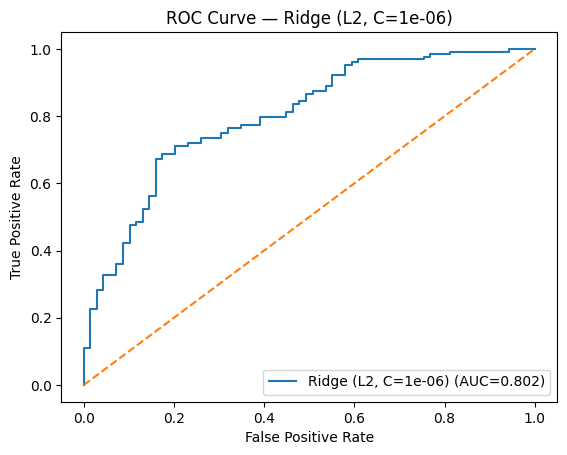

Ridge (L2) over C:   4%|▍         | 1/25 [00:54<21:36, 54.02s/it]

   -> n_iter_: [17] | max_iter: 5000
   -> CV_AUC=0.724 ± 0.030
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   14.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   14.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   14.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   15.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   15.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    5.6s finished


Ridge (L2, C=2.1544346900318822e-06): CV_AUC=...  train_AUC=1.000  test_AUC=0.815  nonzero_coef=759031


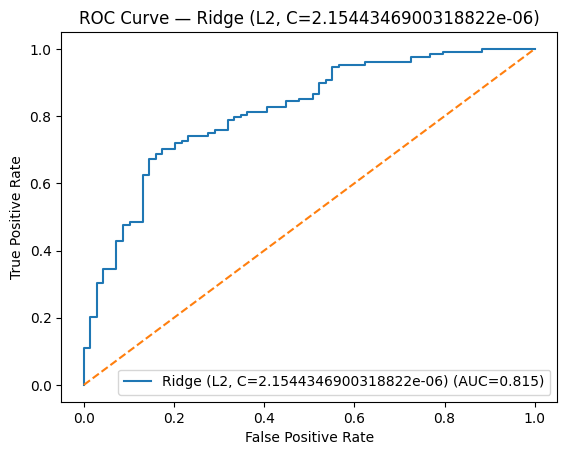

Ridge (L2) over C:   8%|▊         | 2/25 [01:46<20:19, 53.02s/it]

   -> n_iter_: [16] | max_iter: 5000
   -> CV_AUC=0.738 ± 0.031
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   14.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   15.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   15.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   16.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   16.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    6.3s finished


Ridge (L2, C=4.641588833612782e-06): CV_AUC=...  train_AUC=1.000  test_AUC=0.830  nonzero_coef=759161


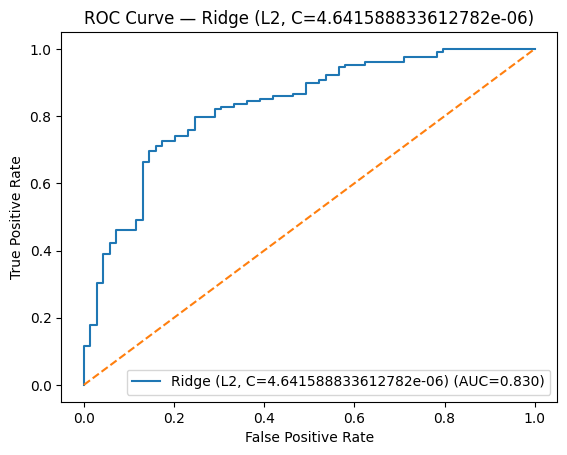

Ridge (L2) over C:  12%|█▏        | 3/25 [02:40<19:38, 53.59s/it]

   -> n_iter_: [18] | max_iter: 5000
   -> CV_AUC=0.755 ± 0.029
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   18.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   18.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   18.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   19.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   18.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    7.2s finished


Ridge (L2, C=1e-05): CV_AUC=...  train_AUC=1.000  test_AUC=0.841  nonzero_coef=759229


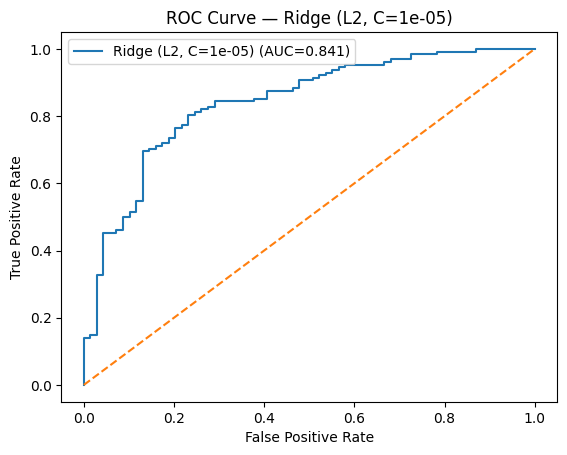

Ridge (L2) over C:  16%|█▌        | 4/25 [03:36<19:04, 54.50s/it]

   -> n_iter_: [20] | max_iter: 5000
   -> CV_AUC=0.768 ± 0.028
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   19.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   19.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   19.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   20.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   21.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    8.1s finished


Ridge (L2, C=2.1544346900318823e-05): CV_AUC=...  train_AUC=1.000  test_AUC=0.856  nonzero_coef=759255


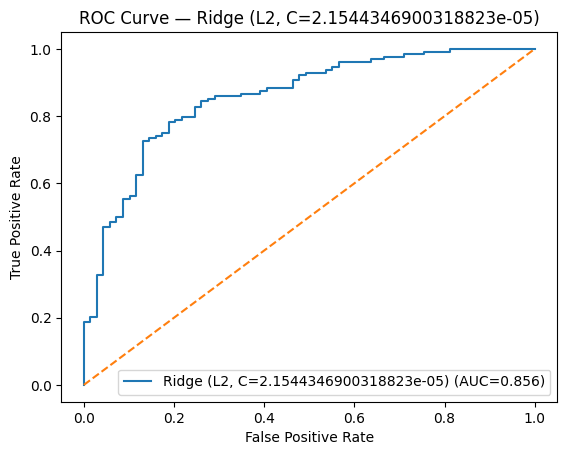

Ridge (L2) over C:  20%|██        | 5/25 [04:34<18:34, 55.73s/it]

   -> n_iter_: [21] | max_iter: 5000
   -> CV_AUC=0.785 ± 0.027
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   20.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   20.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   22.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   22.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   22.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    9.0s finished


Ridge (L2, C=4.641588833612772e-05): CV_AUC=...  train_AUC=1.000  test_AUC=0.866  nonzero_coef=759280


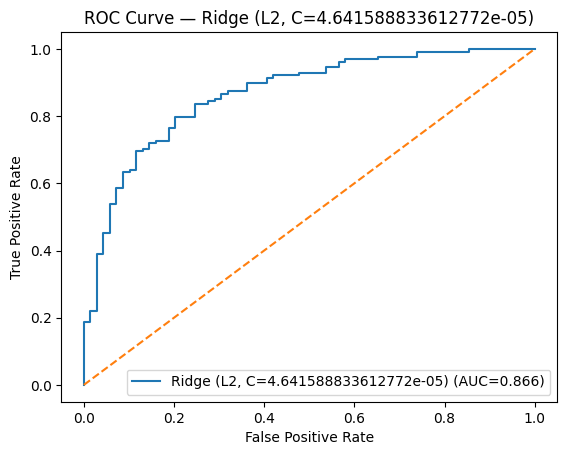

Ridge (L2) over C:  24%|██▍       | 6/25 [05:35<18:10, 57.42s/it]

   -> n_iter_: [25] | max_iter: 5000
   -> CV_AUC=0.797 ± 0.026
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   27.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   29.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   29.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   30.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   30.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   12.5s finished


Ridge (L2, C=0.0001): CV_AUC=...  train_AUC=1.000  test_AUC=0.860  nonzero_coef=759288


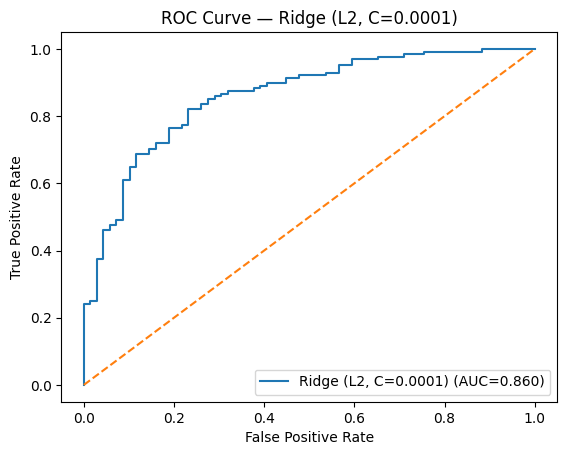

Ridge (L2) over C:  28%|██▊       | 7/25 [06:47<18:39, 62.17s/it]

   -> n_iter_: [32] | max_iter: 5000
   -> CV_AUC=0.804 ± 0.030
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   29.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   29.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   32.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   32.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   33.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   14.2s finished


Ridge (L2, C=0.00021544346900318823): CV_AUC=...  train_AUC=1.000  test_AUC=0.833  nonzero_coef=759298


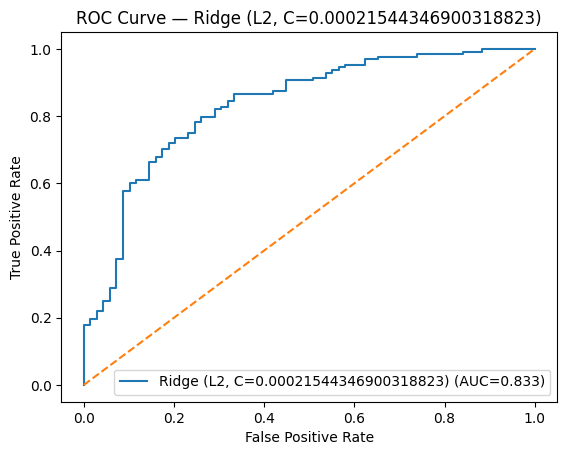

Ridge (L2) over C:  32%|███▏      | 8/25 [08:04<18:56, 66.88s/it]

   -> n_iter_: [38] | max_iter: 5000
   -> CV_AUC=0.815 ± 0.028
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   29.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   36.3s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   36.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   36.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   39.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   15.1s finished


Ridge (L2, C=0.00046415888336127773): CV_AUC=...  train_AUC=1.000  test_AUC=0.849  nonzero_coef=759298


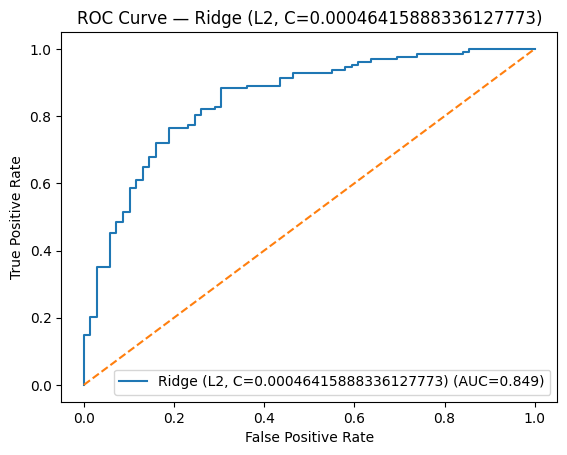

Ridge (L2) over C:  36%|███▌      | 9/25 [09:27<19:14, 72.18s/it]

   -> n_iter_: [40] | max_iter: 5000
   -> CV_AUC=0.817 ± 0.033
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   39.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   40.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   41.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   43.6s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   45.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   16.4s finished


Ridge (L2, C=0.001): CV_AUC=...  train_AUC=1.000  test_AUC=0.833  nonzero_coef=759300


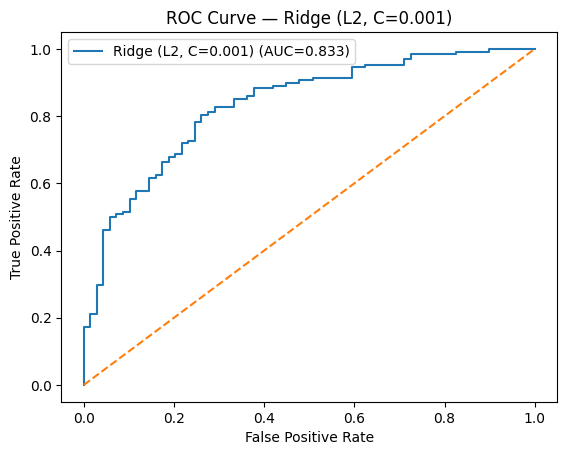

Ridge (L2) over C:  40%|████      | 10/25 [10:57<19:25, 77.67s/it]

   -> n_iter_: [42] | max_iter: 5000
   -> CV_AUC=0.824 ± 0.026
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   38.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   39.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   45.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   45.9s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   48.5s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   18.9s finished


Ridge (L2, C=0.002154434690031882): CV_AUC=...  train_AUC=1.000  test_AUC=0.875  nonzero_coef=759323


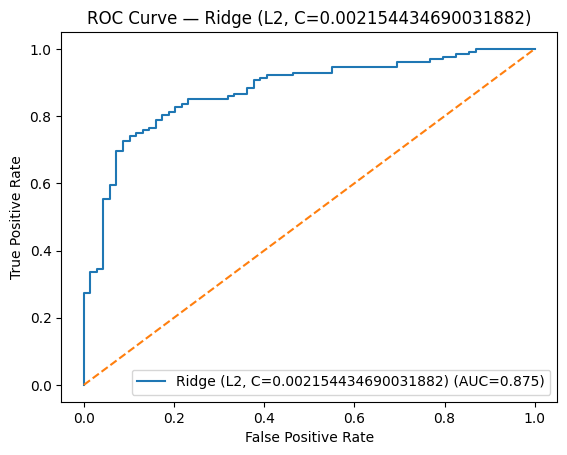

Ridge (L2) over C:  44%|████▍     | 11/25 [12:34<19:27, 83.38s/it]

   -> n_iter_: [47] | max_iter: 5000
   -> CV_AUC=0.829 ± 0.026
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   54.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   57.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   58.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.0min finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:  1.2min finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   19.8s finished


Ridge (L2, C=0.004641588833612777): CV_AUC=...  train_AUC=1.000  test_AUC=0.818  nonzero_coef=759321


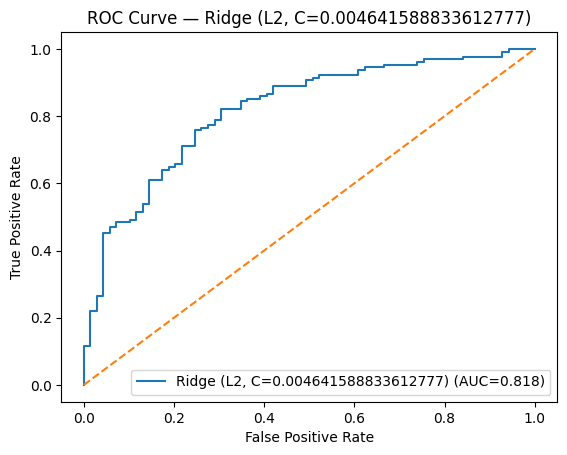

Ridge (L2) over C:  48%|████▊     | 12/25 [14:33<20:27, 94.43s/it]

   -> n_iter_: [50] | max_iter: 5000
   -> CV_AUC=0.805 ± 0.048
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    4.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    5.2s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    8.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:   54.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.5s finished


Ridge (L2, C=0.01): CV_AUC=...  train_AUC=1.000  test_AUC=0.823  nonzero_coef=759338


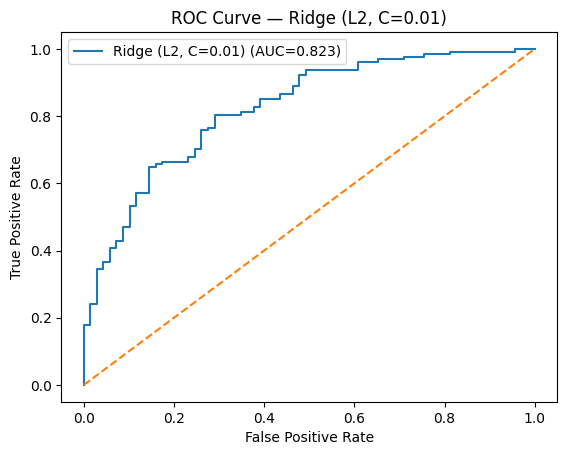

Ridge (L2) over C:  52%|█████▏    | 13/25 [15:57<18:15, 91.31s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.760 ± 0.053
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.3s finished


Ridge (L2, C=0.021544346900318822): CV_AUC=...  train_AUC=1.000  test_AUC=0.822  nonzero_coef=759344


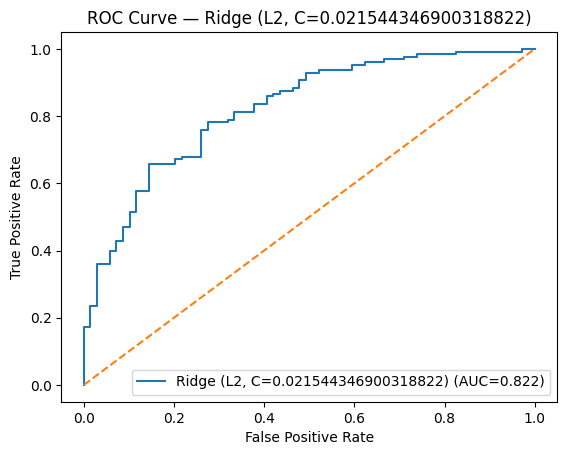

Ridge (L2) over C:  56%|█████▌    | 14/25 [16:32<13:34, 74.07s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.732 ± 0.033
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.4s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.3s finished


Ridge (L2, C=0.046415888336127725): CV_AUC=...  train_AUC=1.000  test_AUC=0.822  nonzero_coef=759340


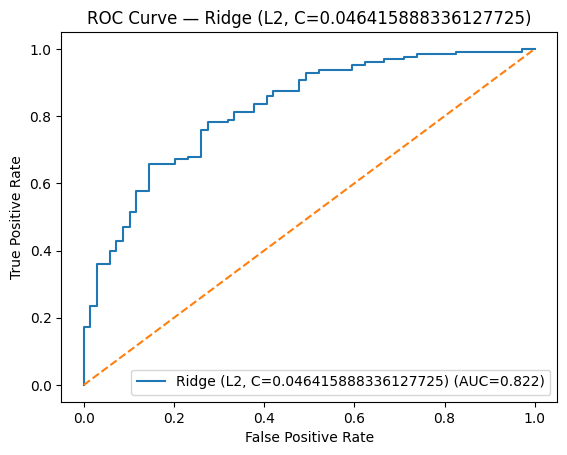

Ridge (L2) over C:  60%|██████    | 15/25 [17:10<10:33, 63.32s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.732 ± 0.034
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.3s finished


Ridge (L2, C=0.1): CV_AUC=...  train_AUC=1.000  test_AUC=0.822  nonzero_coef=759341


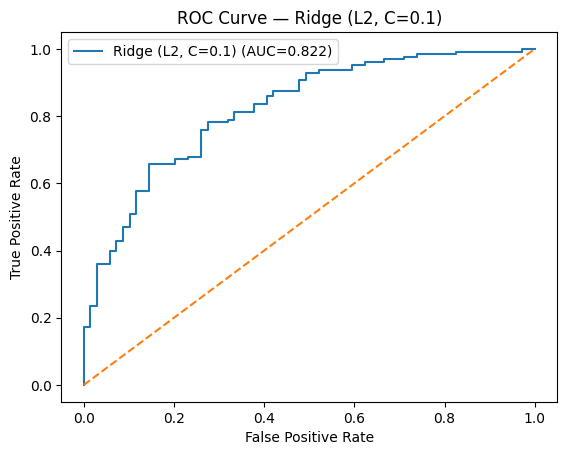

Ridge (L2) over C:  64%|██████▍   | 16/25 [17:44<08:10, 54.51s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.732 ± 0.034
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.3s finished


Ridge (L2, C=0.21544346900318823): CV_AUC=...  train_AUC=1.000  test_AUC=0.822  nonzero_coef=759340


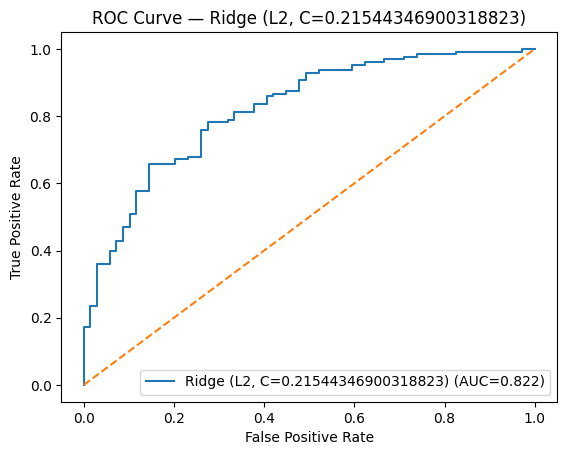

Ridge (L2) over C:  68%|██████▊   | 17/25 [18:18<06:26, 48.34s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.732 ± 0.034
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.2s finished


Ridge (L2, C=0.46415888336127725): CV_AUC=...  train_AUC=1.000  test_AUC=0.822  nonzero_coef=759341


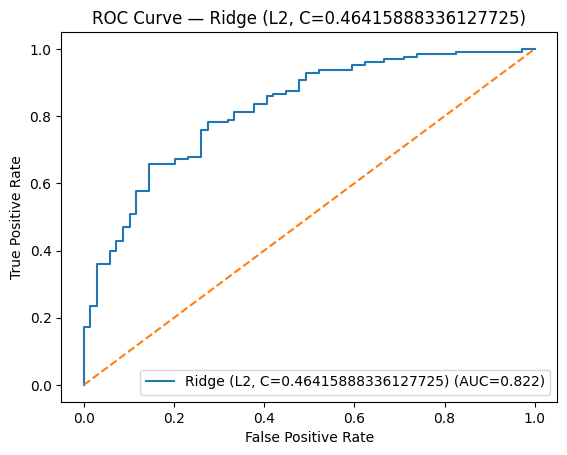

Ridge (L2) over C:  72%|███████▏  | 18/25 [18:52<05:08, 44.03s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.732 ± 0.034
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.2s finished


Ridge (L2, C=1.0): CV_AUC=...  train_AUC=1.000  test_AUC=0.822  nonzero_coef=759342


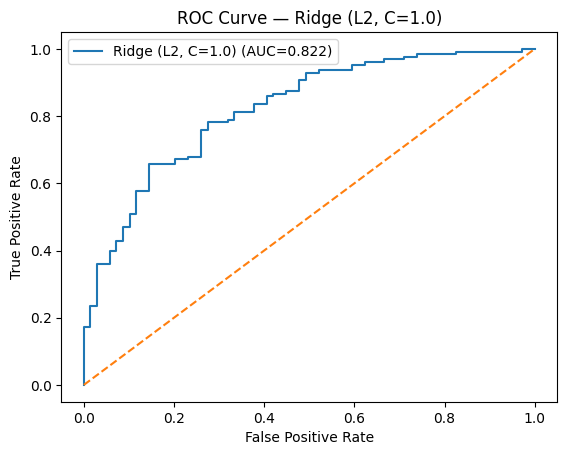

Ridge (L2) over C:  76%|███████▌  | 19/25 [19:27<04:06, 41.14s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.732 ± 0.034
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.1s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.2s finished


Ridge (L2, C=2.154434690031882): CV_AUC=...  train_AUC=1.000  test_AUC=0.822  nonzero_coef=759340


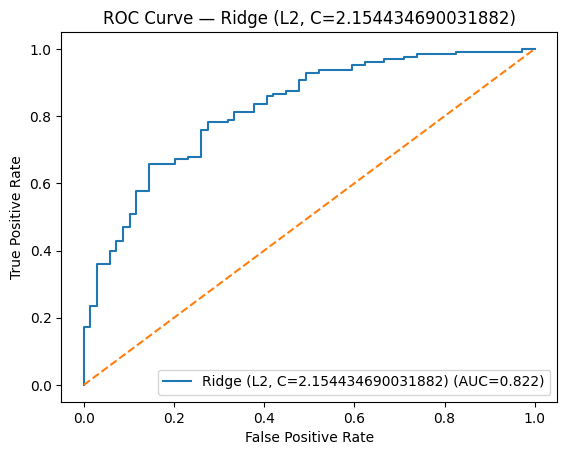

Ridge (L2) over C:  80%|████████  | 20/25 [20:00<03:14, 38.97s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.732 ± 0.034
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.1s finished


Ridge (L2, C=4.641588833612772): CV_AUC=...  train_AUC=1.000  test_AUC=0.822  nonzero_coef=759339


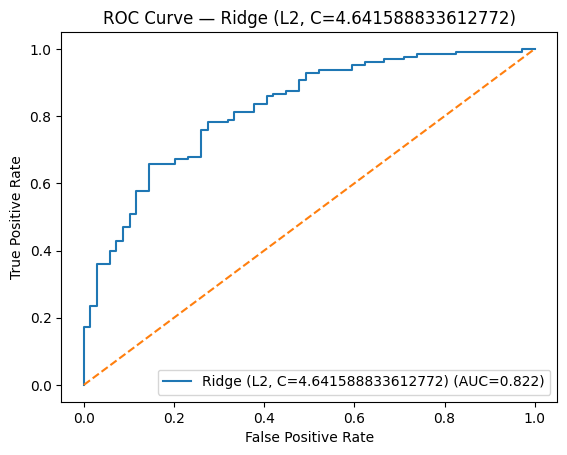

Ridge (L2) over C:  84%|████████▍ | 21/25 [20:35<02:29, 37.49s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.732 ± 0.034
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.3s finished


Ridge (L2, C=10.0): CV_AUC=...  train_AUC=1.000  test_AUC=0.822  nonzero_coef=759340


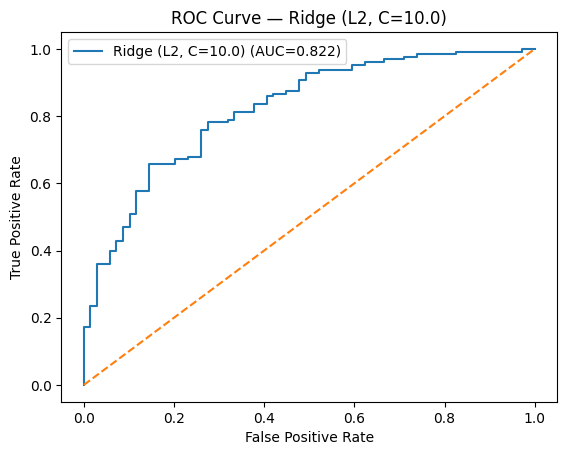

Ridge (L2) over C:  88%|████████▊ | 22/25 [21:09<01:49, 36.55s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.732 ± 0.034
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.2s finished


Ridge (L2, C=21.54434690031882): CV_AUC=...  train_AUC=1.000  test_AUC=0.822  nonzero_coef=759339


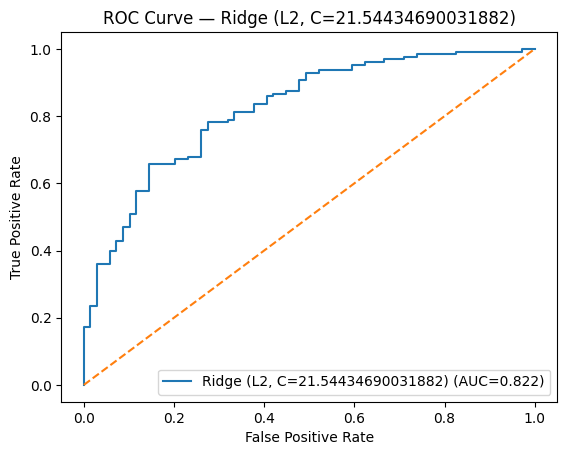

Ridge (L2) over C:  92%|█████████▏| 23/25 [21:43<01:11, 35.84s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.732 ± 0.034
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.3s finished


Ridge (L2, C=46.41588833612773): CV_AUC=...  train_AUC=1.000  test_AUC=0.822  nonzero_coef=759338


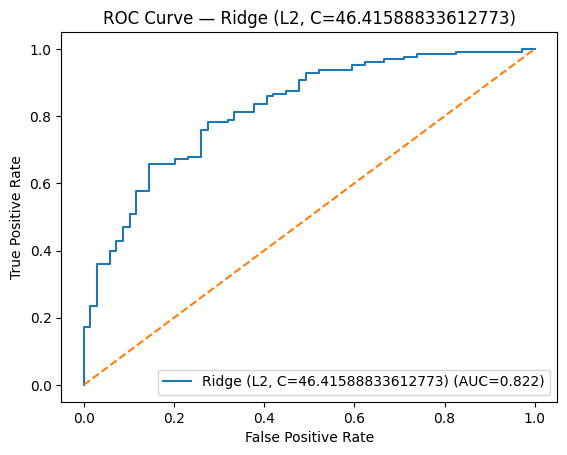

Ridge (L2) over C:  96%|█████████▌| 24/25 [22:17<00:35, 35.31s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.732 ± 0.034
------------------------------------------------------------


[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.0s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.7s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    3.8s finished
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    1.3s finished


Ridge (L2, C=100.0): CV_AUC=...  train_AUC=1.000  test_AUC=0.822  nonzero_coef=759338


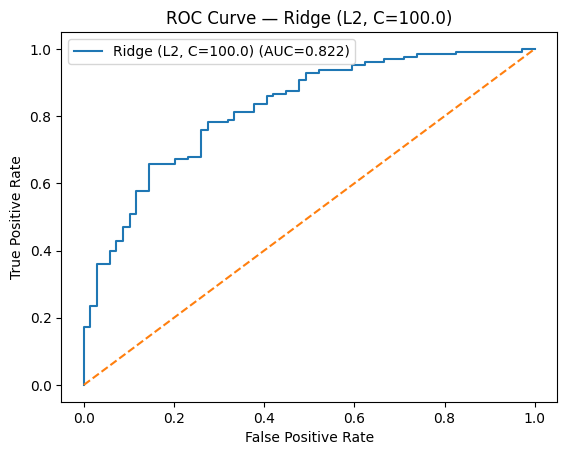

Ridge (L2) over C: 100%|██████████| 25/25 [22:51<00:00, 54.88s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.732 ± 0.034
------------------------------------------------------------


In [41]:
# Detect sparse matrix
is_sparse = sparse.issparse(X_train)
with_mean = not is_sparse  # can't center sparse matrices

for C_val in tqdm(Cs, desc="Ridge (L2) over C"):

    ridge_pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=with_mean)),
        ("logreg", LogisticRegression(
            penalty="l2",
            C=C_val,
            solver="lbfgs" if not is_sparse else "saga",
            max_iter=5000,
            tol=1e-3,
            verbose=1 if not is_sparse else 1,
            n_jobs=-1 if is_sparse else None
        ))
    ])

    # ----- Cross-validation -----
    cv_mean, cv_std = cv_auc(
        ridge_pipe,
        X_train,
        y_train,
        n_splits=5,
        random_state=42
    )

    # ----- Fit on full training set -----
    r = eval_model(
        f"Ridge (L2, C={C_val})",
        ridge_pipe,
        X_train,
        y_train,
        X_test,
        y_test
    )

    # ----- Convergence info -----
    logreg = r["model"].named_steps["logreg"]
    print("   -> n_iter_:", logreg.n_iter_, "| max_iter:", logreg.max_iter)

    r["penalty"] = "L2"
    r["C"] = C_val
    r["cv_auc_mean"] = cv_mean
    r["cv_auc_std"]  = cv_std

    print(f"   -> CV_AUC={cv_mean:.3f} ± {cv_std:.3f}")
    print("-" * 60)

    all_results.append(r)

In [42]:
# Ridge results 
ridge_df = pd.DataFrame([
    {
        "C": r["C"],
        "train_auc": r["train_auc"],
        "test_auc": r["test_auc"],
        "cv_auc_mean": r["cv_auc_mean"],
        "cv_auc_std": r["cv_auc_std"]
    }
    for r in all_results
    if r["penalty"] == "L2"
]).sort_values("C")

ridge_df

,C,train_auc,test_auc,cv_auc_mean,cv_auc_std
0,0.000001,0.99976,0.801517,0.724306,0.030343
1,0.000002,1.00000,0.814764,0.738375,0.030754
2,0.000005,1.00000,0.830276,0.755225,0.028807
3,0.000010,1.00000,0.840580,0.767640,0.028272
4,0.000022,1.00000,0.856431,0.784586,0.026584
5,0.000046,1.00000,0.865829,0.796955,0.026368
6,0.000100,1.00000,0.860054,0.803699,0.029919
7,0.000215,1.00000,0.833333,0.815132,0.027946
8,0.000464,1.00000,0.849072,0.816858,0.033382
9,0.001000,1.00000,0.833220,0.823771,0.026462


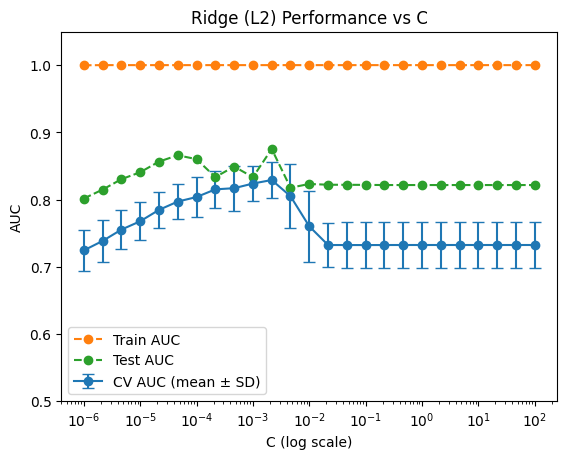

In [43]:
plt.figure()

# CV mean ± SD
plt.errorbar(
    ridge_df["C"],
    ridge_df["cv_auc_mean"],
    yerr=ridge_df["cv_auc_std"],
    fmt="o-",
    capsize=4,
    label="CV AUC (mean ± SD)"
)

# Train and Test
plt.plot(ridge_df["C"], ridge_df["train_auc"], "o--", label="Train AUC")
plt.plot(ridge_df["C"], ridge_df["test_auc"],  "o--", label="Test AUC")

plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("AUC")
plt.title("Ridge (L2) Performance vs C")
plt.ylim(0.5, 1.05)
plt.legend()
plt.show()

#### we select C value based on best CV AUC
#### the best performing C (regularization value) was: 0.002154, with an test AUC of 0.875226 and CV AUC of 0.829021

### lasso regression

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 1 epochs took 11 seconds
Lasso (L1, C=1e-06): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


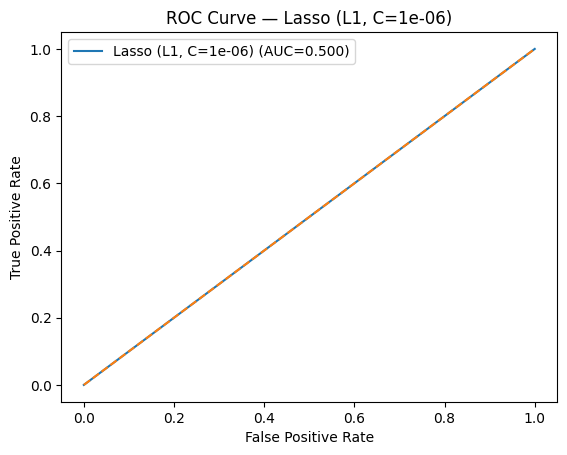

Lasso (L1) over C:   4%|▍         | 1/25 [00:45<18:01, 45.07s/it]

   -> n_iter_: [1] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 1 epochs took 13 seconds
Lasso (L1, C=2.1544346900318822e-06): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


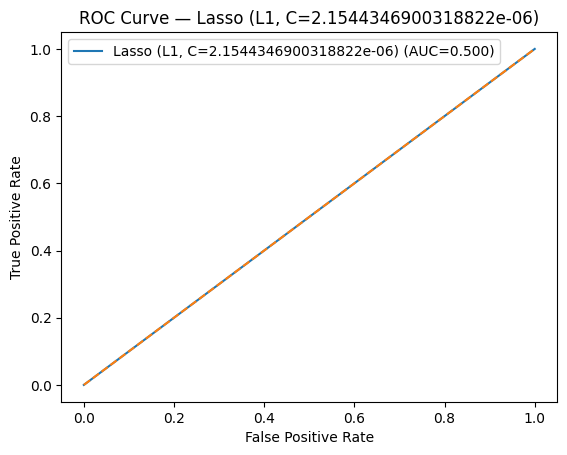

Lasso (L1) over C:   8%|▊         | 2/25 [01:30<17:27, 45.53s/it]

   -> n_iter_: [1] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 1 epochs took 12 seconds
Lasso (L1, C=4.641588833612782e-06): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


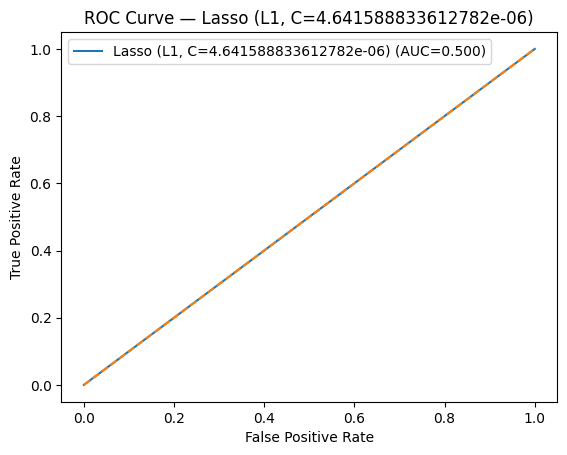

Lasso (L1) over C:  12%|█▏        | 3/25 [02:15<16:33, 45.14s/it]

   -> n_iter_: [1] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 1 epochs took 11 seconds
Lasso (L1, C=1e-05): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


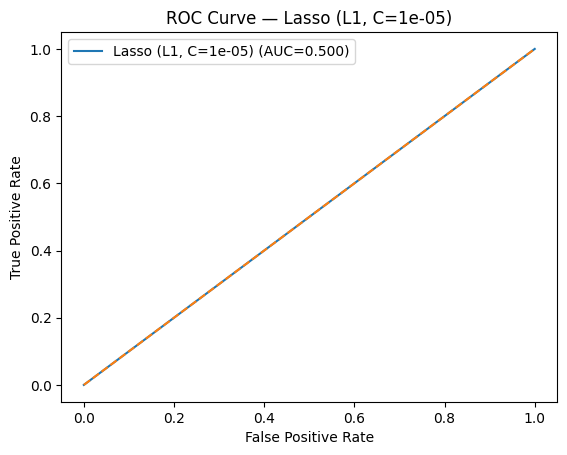

Lasso (L1) over C:  16%|█▌        | 4/25 [03:00<15:45, 45.01s/it]

   -> n_iter_: [1] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 1 epochs took 11 seconds
Lasso (L1, C=2.1544346900318823e-05): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


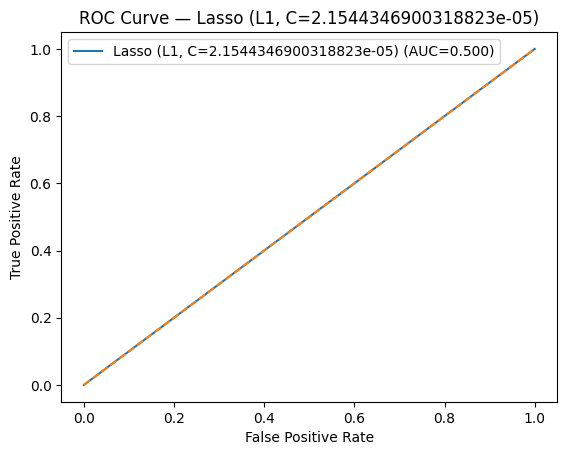

Lasso (L1) over C:  20%|██        | 5/25 [03:44<14:56, 44.83s/it]

   -> n_iter_: [1] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 1 epochs took 12 seconds
Lasso (L1, C=4.641588833612772e-05): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


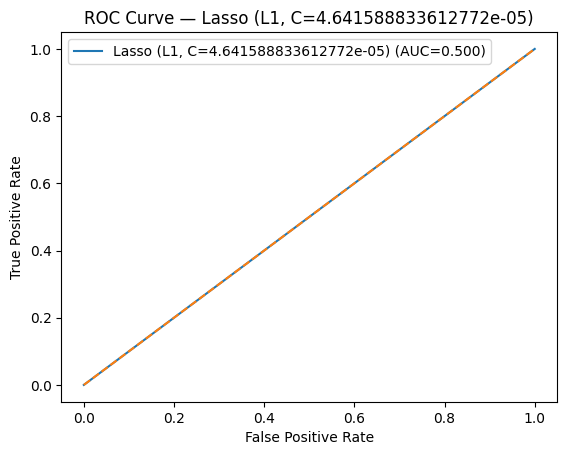

Lasso (L1) over C:  24%|██▍       | 6/25 [04:29<14:12, 44.89s/it]

   -> n_iter_: [1] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 1 epochs took 12 seconds
Lasso (L1, C=0.0001): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


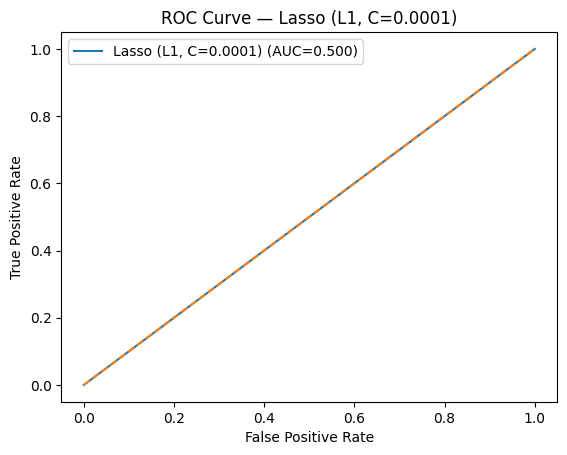

Lasso (L1) over C:  28%|██▊       | 7/25 [05:15<13:29, 44.98s/it]

   -> n_iter_: [1] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 1 epochs took 11 seconds
Lasso (L1, C=0.00021544346900318823): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


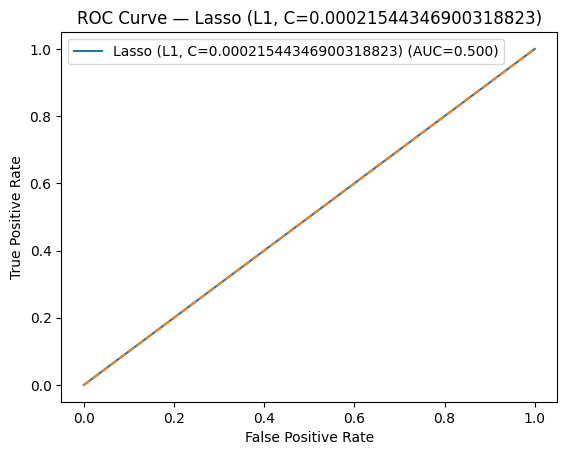

Lasso (L1) over C:  32%|███▏      | 8/25 [06:27<15:12, 53.65s/it]

   -> n_iter_: [1] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 3 epochs took 36 seconds
Lasso (L1, C=0.00046415888336127773): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


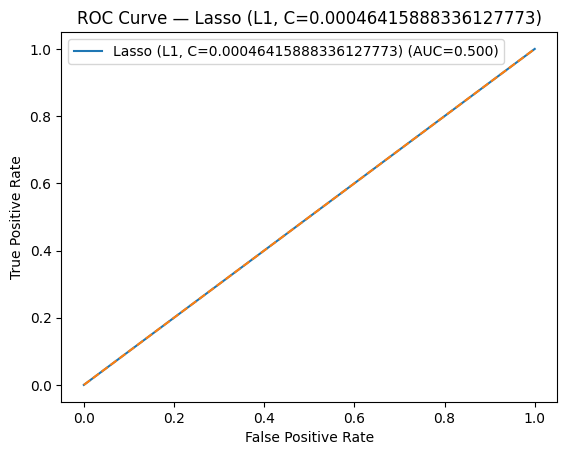

Lasso (L1) over C:  36%|███▌      | 9/25 [08:15<18:53, 70.84s/it]

   -> n_iter_: [3] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 1 epochs took 10 seconds
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 9 seconds
convergence after 4 epochs took 45 seconds
Lasso (L1, C=0.001): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


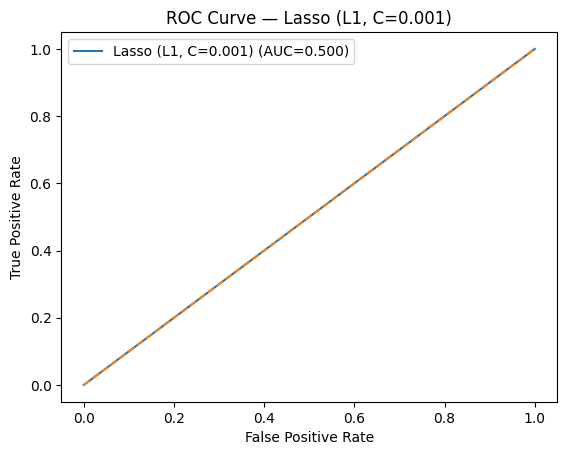

Lasso (L1) over C:  40%|████      | 10/25 [10:21<21:55, 87.69s/it]

   -> n_iter_: [4] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 10 seconds
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 10 seconds
convergence after 1 epochs took 9 seconds
convergence after 4 epochs took 37 seconds
Epoch 1, change: 1
Epoch 2, change: 1
Epoch 3, change: inf
convergence after 1 epochs took 10 seconds
convergence after 1 epochs took 10 seconds
convergence after 5 epochs took 48 seconds
Epoch 1, change: 1
Epoch 2, change: 1
Epoch 3, change: 2.3076544
Epoch 4, change: inf
convergence after 6 epochs took 70 seconds
Lasso (L1, C=0.002154434690031882): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


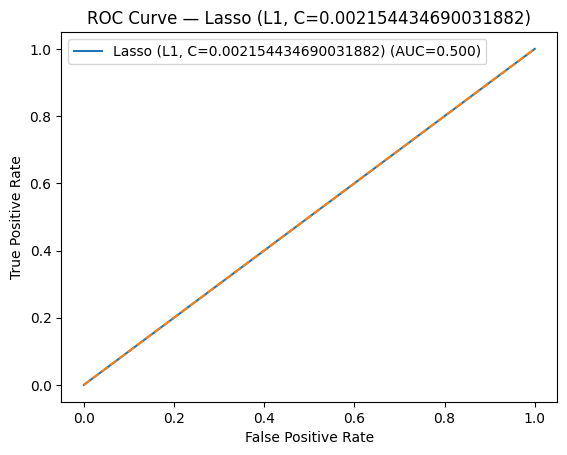

Lasso (L1) over C:  44%|████▍     | 11/25 [12:51<24:55, 106.79s/it]

   -> n_iter_: [6] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 7 epochs took 89 seconds
Lasso (L1, C=0.004641588833612777): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


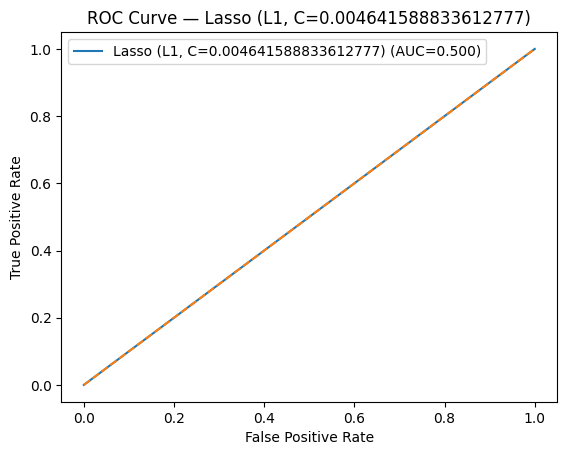

Lasso (L1) over C:  48%|████▊     | 12/25 [15:43<27:25, 126.55s/it]

   -> n_iter_: [7] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 1 epochs took 10 seconds
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 9 seconds
convergence after 6 epochs took 56 seconds
convergence after 5 epochs took 49 seconds
Epoch 1, change: 1
Epoch 2, change: 1.3890646
Epoch 3, change: inf
Epoch 4, change: 1
Epoch 5, change: inf
Epoch 1, change: 1
Epoch 2, change: 1.6080182
Epoch 3, change: 1
Epoch 4, change: inf
convergence after 1 epochs took 10 seconds
convergence after 1 epochs took 9 seconds
convergence after 6 epochs took 56 seconds
convergence after 5 epochs took 51 seconds
Epoch 1, change: 1
Epoch 2, change: inf
Epoch 3, change: 1
Epoch 4, change: 1
Epoch 5, change: inf
Epoch 1, change: 1
Epoch 2, change: 1
Epoch 3, change: 1.1579514
Epoch 4, change: inf
convergence after 7 epochs took 91 seconds
Lasso (L1, C=0.01): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


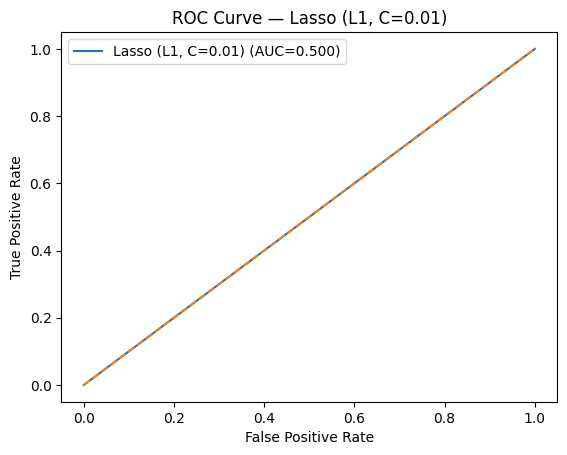

Lasso (L1) over C:  52%|█████▏    | 13/25 [19:00<29:35, 147.93s/it]

   -> n_iter_: [7] | max_iter: 5000
   -> CV_AUC=0.500 ± 0.000
------------------------------------------------------------
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 10 seconds
convergence after 4 epochs took 37 seconds
convergence after 6 epochs took 58 seconds
Epoch 1, change: 1
Epoch 2, change: 9.7373848
Epoch 3, change: inf
Epoch 1, change: 1
Epoch 2, change: 1
Epoch 3, change: inf
Epoch 4, change: 1
Epoch 5, change: inf
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 10 seconds
convergence after 3 epochs took 29 seconds
convergence after 6 epochs took 58 seconds
Epoch 1, change: 1
Epoch 2, change: inf
Epoch 1, change: 1
Epoch 2, change: 1.5824596
Epoch 3, change: 1
Epoch 4, change: 3.7478821
Epoch 5, change: inf
convergence after 1 epochs took 10 seconds
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 9 seconds
convergence after 5 epochs took 47 seconds
con

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 9 seconds
convergence after 1 epochs took 9 seconds
convergence after 5 epochs took 47 seconds
convergence after 8 epochs took 82 seconds
Epoch 1, change: 1
Epoch 2, change: 1
Epoch 3, change: 2.4819138
Epoch 4, change: inf
Epoch 1, change: 1
Epoch 2, change: 1.8801351
Epoch 3, change: 2.1060255
Epoch 4, change: 7.8635306
Epoch 5, change: inf
Epoch 6, change: 1
Epoch 7, change: inf


In [ ]:
# ----------------------------
# ✂️ Lasso (L1) grid + k-fold CV (with scaling + verbosity)
# ----------------------------
is_sparse = sparse.issparse(X_train)
with_mean = not is_sparse  # can't center sparse matrices

for C_val in tqdm(Cs, desc="Lasso (L1) over C"):

    lasso_pipe = Pipeline([
        ("scaler", StandardScaler(with_mean=with_mean)),
        ("logreg", LogisticRegression(
            penalty="l1",
            C=C_val,
            solver="saga",
            max_iter=5000,
            tol=1e-3,
            n_jobs=-1,
            verbose=1
        ))
    ])

    # ----- Cross-validation -----
    cv_mean, cv_std = cv_auc(
        lasso_pipe,
        X_train,
        y_train,
        n_splits=5,
        random_state=42
    )

    # ----- Fit on full training set -----
    r = eval_model(
        f"Lasso (L1, C={C_val})",
        lasso_pipe,
        X_train,
        y_train,
        X_test,
        y_test
    )

    # ----- Convergence info -----
    logreg = r["model"].named_steps["logreg"]
    print("   -> n_iter_:", logreg.n_iter_, "| max_iter:", logreg.max_iter)

    r["penalty"] = "L1"
    r["C"] = C_val
    r["cv_auc_mean"] = cv_mean
    r["cv_auc_std"]  = cv_std

    print(f"   -> CV_AUC={cv_mean:.3f} ± {cv_std:.3f}")
    print("-" * 60)

    all_results.append(r)

### elastic net regression

In [17]:
Cs = np.logspace(-6, 2, 25)   
l1_ratios = [0.1, 0.2, 0.3]

ElasticNet l1_ratio=0.1:   0%|          | 0/25 [00:00<?, ?it/s]

ElasticNet (C=1.00e-06, l1_ratio=0.1): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


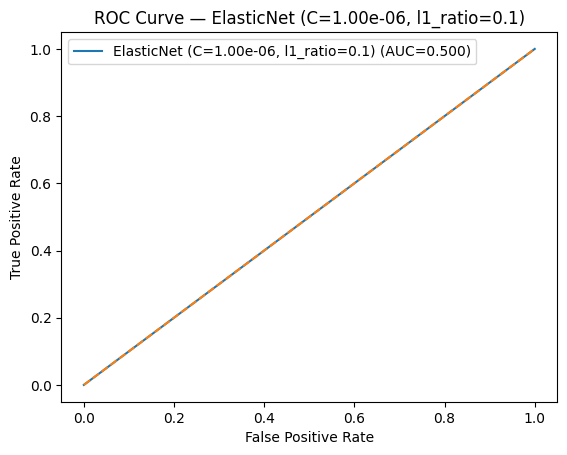

ElasticNet l1_ratio=0.1:   4%|▍         | 1/25 [00:48<19:22, 48.42s/it]

   -> n_iter_: [1]
   -> CV_AUC=0.500 ± 0.000 | train_AUC=0.500 | test_AUC=0.500
------------------------------------------------------------
ElasticNet (C=2.15e-06, l1_ratio=0.1): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


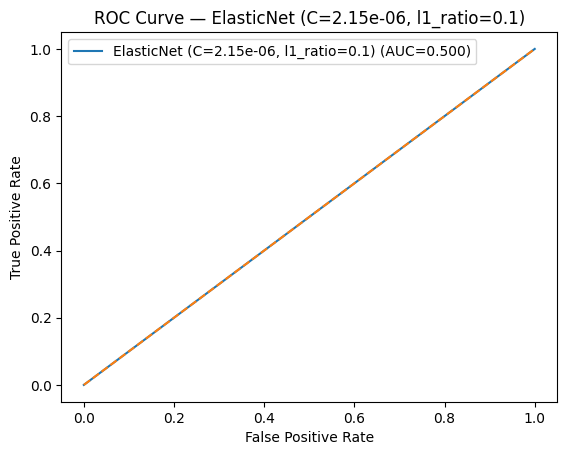

ElasticNet l1_ratio=0.1:   8%|▊         | 2/25 [01:36<18:24, 48.00s/it]

   -> n_iter_: [1]
   -> CV_AUC=0.500 ± 0.000 | train_AUC=0.500 | test_AUC=0.500
------------------------------------------------------------
ElasticNet (C=4.64e-06, l1_ratio=0.1): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


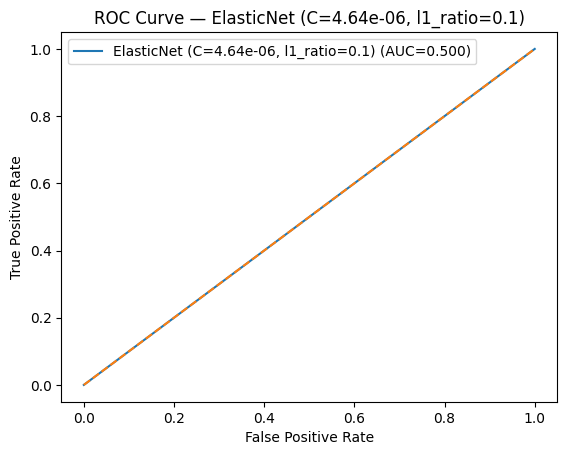

ElasticNet l1_ratio=0.1:  12%|█▏        | 3/25 [02:24<17:35, 47.97s/it]

   -> n_iter_: [1]
   -> CV_AUC=0.500 ± 0.000 | train_AUC=0.500 | test_AUC=0.500
------------------------------------------------------------
ElasticNet (C=1.00e-05, l1_ratio=0.1): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


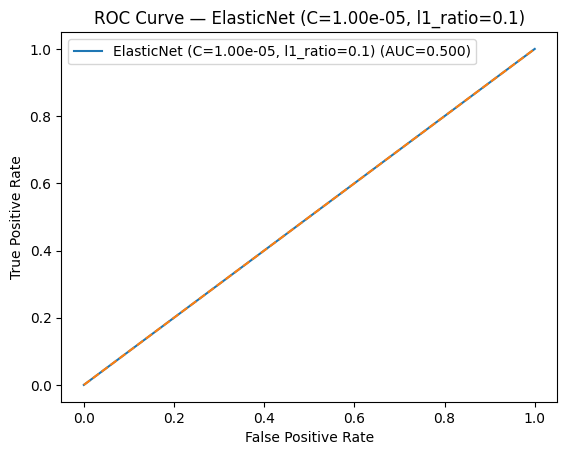

ElasticNet l1_ratio=0.1:  16%|█▌        | 4/25 [03:34<19:50, 56.70s/it]

   -> n_iter_: [3]
   -> CV_AUC=0.500 ± 0.000 | train_AUC=0.500 | test_AUC=0.500
------------------------------------------------------------
ElasticNet (C=2.15e-05, l1_ratio=0.1): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


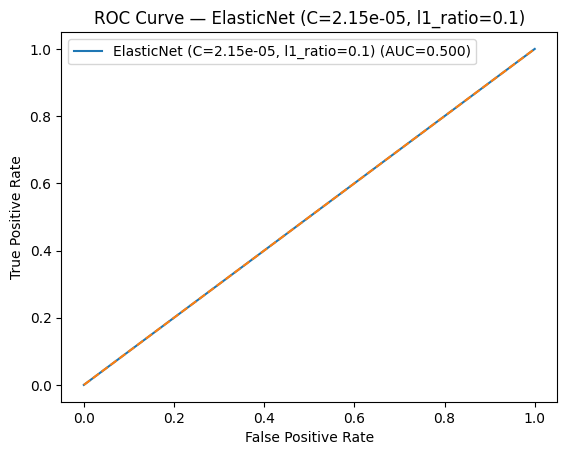

ElasticNet l1_ratio=0.1:  20%|██        | 5/25 [05:01<22:33, 67.68s/it]

   -> n_iter_: [3]
   -> CV_AUC=0.500 ± 0.000 | train_AUC=0.500 | test_AUC=0.500
------------------------------------------------------------
ElasticNet (C=4.64e-05, l1_ratio=0.1): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


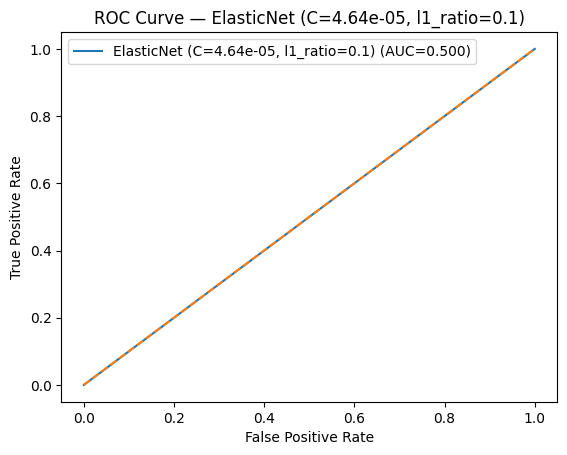

ElasticNet l1_ratio=0.1:  24%|██▍       | 6/25 [06:48<25:40, 81.06s/it]

   -> n_iter_: [3]
   -> CV_AUC=0.500 ± 0.000 | train_AUC=0.500 | test_AUC=0.500
------------------------------------------------------------
ElasticNet (C=1.00e-04, l1_ratio=0.1): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


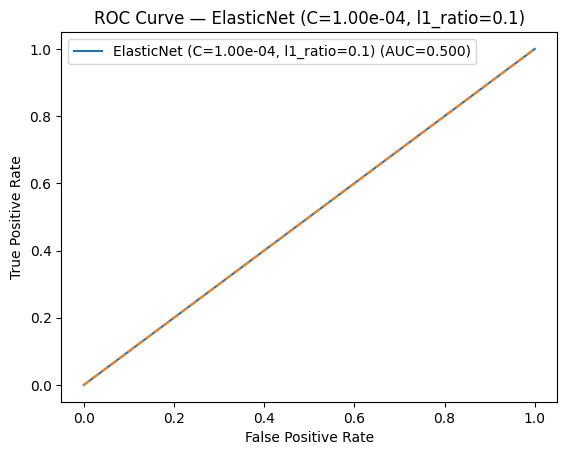

ElasticNet l1_ratio=0.1:  28%|██▊       | 7/25 [09:06<29:56, 99.78s/it]

   -> n_iter_: [5]
   -> CV_AUC=0.500 ± 0.000 | train_AUC=0.500 | test_AUC=0.500
------------------------------------------------------------
ElasticNet (C=2.15e-04, l1_ratio=0.1): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


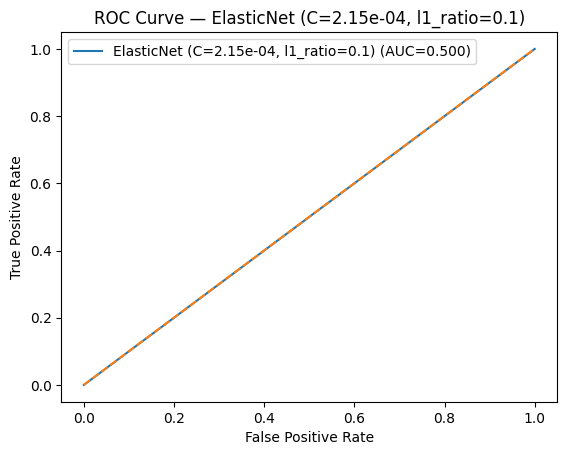

ElasticNet l1_ratio=0.1:  32%|███▏      | 8/25 [11:51<34:07, 120.45s/it]

   -> n_iter_: [7]
   -> CV_AUC=0.500 ± 0.000 | train_AUC=0.500 | test_AUC=0.500
------------------------------------------------------------
ElasticNet (C=4.64e-04, l1_ratio=0.1): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


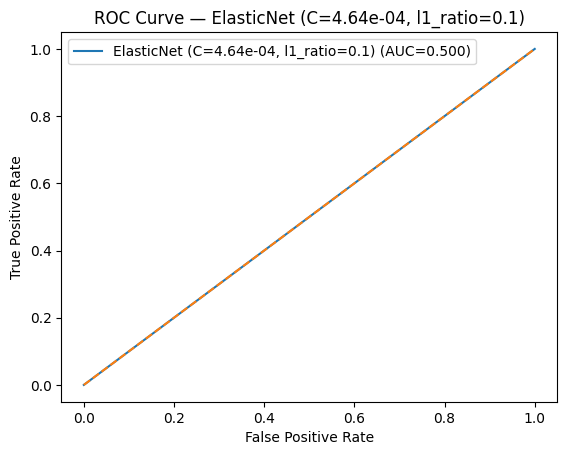

ElasticNet l1_ratio=0.1:  36%|███▌      | 9/25 [14:49<36:54, 138.38s/it]

   -> n_iter_: [7]
   -> CV_AUC=0.500 ± 0.000 | train_AUC=0.500 | test_AUC=0.500
------------------------------------------------------------
ElasticNet (C=1.00e-03, l1_ratio=0.1): CV_AUC=...  train_AUC=0.500  test_AUC=0.500  nonzero_coef=0


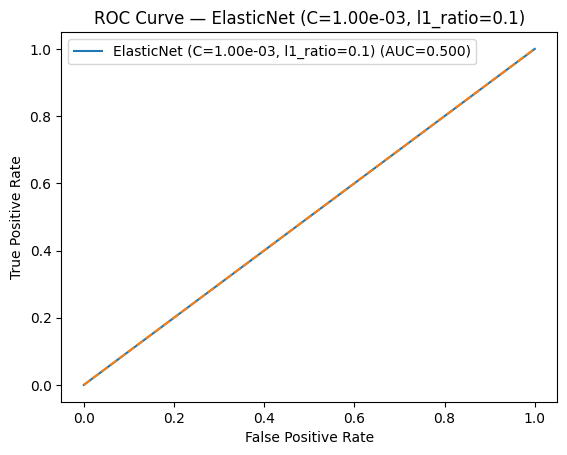

ElasticNet l1_ratio=0.1:  40%|████      | 10/25 [18:07<39:13, 156.90s/it]

   -> n_iter_: [7]
   -> CV_AUC=0.500 ± 0.000 | train_AUC=0.500 | test_AUC=0.500
------------------------------------------------------------


In [ ]:
all_results = []

with_mean = True  # you are dense

for l1_ratio in l1_ratios:
    for C_val in tqdm(Cs, desc=f"ElasticNet l1_ratio={l1_ratio}"):

        enet_pipe = Pipeline([
            ("scaler", StandardScaler(with_mean=with_mean)),
            ("logreg", LogisticRegression(
                penalty="elasticnet",
                solver="saga",
                C=float(C_val),
                l1_ratio=float(l1_ratio),
                class_weight="balanced",
                max_iter=10000,
                tol=1e-4,
                n_jobs=-1,
                random_state=42
            ))
        ])

        cv_mean, cv_std = cv_auc(enet_pipe, X_train, y_train, n_splits=5, random_state=42)

        r = eval_model(
            f"ElasticNet (C={C_val:.2e}, l1_ratio={l1_ratio})",
            enet_pipe,
            X_train, y_train,
            X_test, y_test
        )

        logreg = r["model"].named_steps["logreg"]
        print("   -> n_iter_:", logreg.n_iter_)
        print(f"   -> CV_AUC={cv_mean:.3f} ± {cv_std:.3f} | train_AUC={r['train_auc']:.3f} | test_AUC={r['test_auc']:.3f}")
        print("-" * 60)

        r["penalty"] = "elasticnet"
        r["C"] = float(C_val)
        r["l1_ratio"] = float(l1_ratio)
        r["cv_auc_mean"] = float(cv_mean)
        r["cv_auc_std"] = float(cv_std)

        all_results.append(r)

In [ ]:
enet_df = pd.DataFrame([
    {
        "l1_ratio": r["l1_ratio"],
        "C": r["C"],
        "train_auc": r["train_auc"],
        "test_auc": r["test_auc"],
        "cv_auc_mean": r["cv_auc_mean"],
        "cv_auc_std": r["cv_auc_std"],
        # optional extras if you saved them
        "n_iter": (r["model"].named_steps["logreg"].n_iter_[0]
                   if "model" in r and r["model"] is not None else None)
    }
    for r in all_results
    if r.get("penalty") == "elasticnet"
]).sort_values(["l1_ratio", "C"])

enet_df

In [ ]:
import matplotlib.pyplot as plt

for l1 in sorted(enet_df["l1_ratio"].unique()):
    sub = enet_df[enet_df["l1_ratio"] == l1].sort_values("C")

    plt.figure()

    # CV mean ± SD
    plt.errorbar(
        sub["C"],
        sub["cv_auc_mean"],
        yerr=sub["cv_auc_std"],
        fmt="o-",
        capsize=4,
        label="CV AUC (mean ± SD)"
    )

    # Train and Test
    plt.plot(sub["C"], sub["train_auc"], "o--", label="Train AUC")
    plt.plot(sub["C"], sub["test_auc"],  "o--", label="Test AUC")

    plt.xscale("log")
    plt.xlabel("C (log scale)")
    plt.ylabel("AUC")
    plt.title(f"Elastic Net Performance vs C (l1_ratio={l1})")
    plt.ylim(0.5, 1.05)
    plt.legend()
    plt.show()

#### the best performing C (regularization value) was: 0., with an test AUC of 0. and CV AUC of 0.